# Artificial Immune System for Structure Damage Classification

A simplified implementation for practical exam.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

## 1. Load and Prepare Dataset

In [3]:
# Load dataset (using breast cancer dataset as a proxy for structural damage data)
data = load_breast_cancer()
X = data.data
y = data.target

# Invert the labels (0=undamaged, 1=damaged)
y = 1 - y

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: Undamaged: {np.sum(y == 0)}, Damaged: {np.sum(y == 1)}")

Dataset shape: (569, 30)
Class distribution: Undamaged: 357, Damaged: 212


## 2. Artificial Immune System Classifier

In [4]:
class AIRS:
    """Artificial Immune System for damage classification"""

    def __init__(self, n_detectors=10, mutation_rate=0.1):
        self.n_detectors = n_detectors
        self.mutation_rate = mutation_rate
        self.detectors = None
        self.detector_labels = None

    def affinity(self, x1, x2):
        # Calculate similarity (higher = more similar)
        distance = np.linalg.norm(x1 - x2)
        return 1 / (1 + distance)

    def train(self, X, y):
        # Initialize detector arrays
        self.detectors = []
        self.detector_labels = []

        # Create detectors for each class
        for cls in np.unique(y):
            # Get samples for this class
            class_indices = np.where(y == cls)[0]
            # Choose random samples as initial detectors
            detectors_per_class = max(self.n_detectors // len(np.unique(y)), 1)
            detector_indices = np.random.choice(class_indices, detectors_per_class)

            for idx in detector_indices:
                # Get sample and apply mutation
                detector = X[idx].copy()
                mutation = np.random.normal(0, self.mutation_rate, detector.shape)
                detector += mutation

                self.detectors.append(detector)
                self.detector_labels.append(cls)

        # Convert to numpy arrays
        self.detectors = np.array(self.detectors)
        self.detector_labels = np.array(self.detector_labels)
        print(f"Created {len(self.detectors)} immune system detectors")

    def predict(self, X):
        predictions = []

        for sample in X:
            # Calculate affinity with all detectors
            affinities = [self.affinity(sample, d) for d in self.detectors]
            # Classify based on most similar detector
            best_match = np.argmax(affinities)
            predictions.append(self.detector_labels[best_match])

        return np.array(predictions)

## 3. Train and Test the Model

In [5]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create and train immune system
airs = AIRS(n_detectors=30, mutation_rate=0.1)
airs.train(X_train, y_train)

# Test on unseen data
y_pred = airs.predict(X_test)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Classification accuracy: {accuracy:.4f}")

Created 30 immune system detectors
Classification accuracy: 0.9064


## 4. Visualize Results

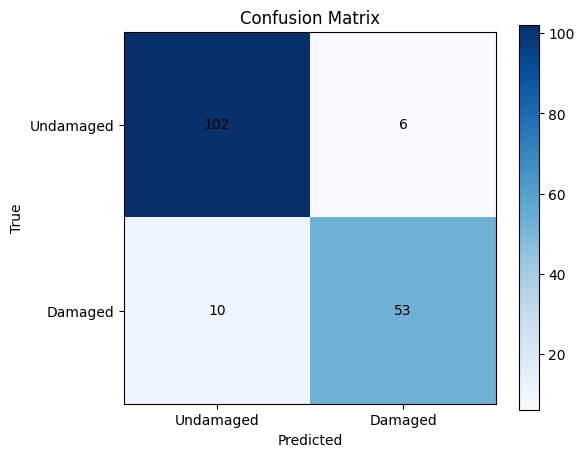

In [6]:
# Create confusion matrix
cm = np.zeros((2, 2), dtype=int)
for true, pred in zip(y_test, y_pred):
    cm[int(true), int(pred)] += 1

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Undamaged", "Damaged"])
plt.yticks([0, 1], ["Undamaged", "Damaged"])

# Add numbers to cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.savefig("damage_classification_results.png")
plt.show()

## 5. Visualize Immune System Detectors

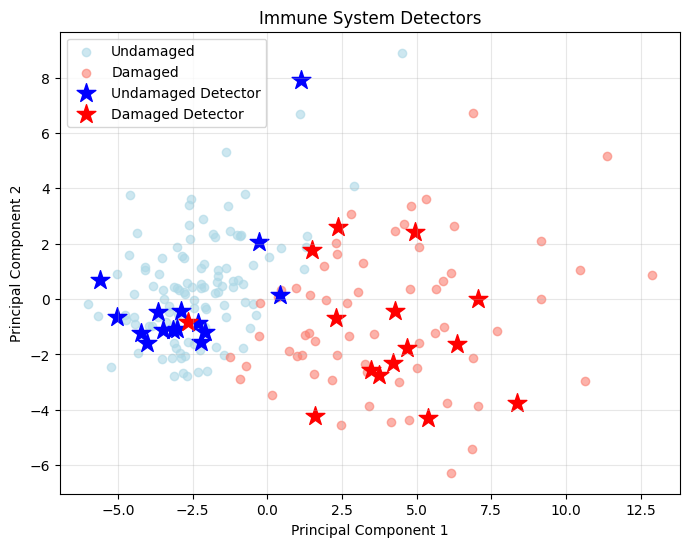

In [7]:
from sklearn.decomposition import PCA

# Use PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_test)
detectors_2d = pca.transform(airs.detectors)

# Plot
plt.figure(figsize=(8, 6))

# Plot test samples
plt.scatter(
    X_2d[y_test == 0, 0],
    X_2d[y_test == 0, 1],
    color="lightblue",
    label="Undamaged",
    alpha=0.6,
)
plt.scatter(
    X_2d[y_test == 1, 0],
    X_2d[y_test == 1, 1],
    color="salmon",
    label="Damaged",
    alpha=0.6,
)

# Plot detectors as stars
plt.scatter(
    detectors_2d[airs.detector_labels == 0, 0],
    detectors_2d[airs.detector_labels == 0, 1],
    color="blue",
    marker="*",
    s=200,
    label="Undamaged Detector",
)
plt.scatter(
    detectors_2d[airs.detector_labels == 1, 0],
    detectors_2d[airs.detector_labels == 1, 1],
    color="red",
    marker="*",
    s=200,
    label="Damaged Detector",
)

plt.title("Immune System Detectors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Conclusion

The Artificial Immune System approach for structural damage classification:

1. Creates detector cells that represent different damage patterns
2. Uses affinity (similarity) to match samples to the nearest detector
3. Simple mutation helps create diverse detector patterns
4. Visualizations show how detectors separate damaged and undamaged structures

This bio-inspired approach is effective for classification tasks while being conceptually simple.